In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent
DB = ROOT / "data" / "ontarget.duckdb"
OUT = ROOT / "data" / "processed" / "players_career.csv"

assert DB.exists(), f"{DB} missing - run `python scripts/build_db.py`"
con = duckdb.connect(str(DB), read_only=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

print(con.execute("SELECT count(*) FROM players").fetchone()[0], "player-seasons")
print(con.execute("SELECT count(*) FROM shots").fetchone()[0], "shots")


13964 player-seasons
224676 shots


In [2]:
career_pos = con.execute("""
    WITH weighted AS (
      SELECT id, primary_position_hierarchy AS pos, sum(time) AS mins
      FROM players
      WHERE primary_position_hierarchy NOT IN ('S', 'GK', 'Other')
      GROUP BY id, primary_position_hierarchy
    ),
    ranked AS (
      SELECT id, pos, mins,
             row_number() OVER (PARTITION BY id ORDER BY mins DESC, pos) AS rn,
             sum(mins) OVER (PARTITION BY id) AS total_mins
      FROM weighted
    )
    SELECT id, pos AS position,
           round(mins * 1.0 / nullif(total_mins, 0), 3) AS pos_share
    FROM ranked WHERE rn = 1
""").df()

# Do the position columns agree? Where they don't, the player genuinely moves
# between roles (a wing-back who plays as a winger) and any single label
# overstates precision. Surfaced rather than hidden.
agreement = con.execute("""
    SELECT id,
           sum(CASE WHEN primary_position = primary_position_hierarchy
                    THEN time ELSE 0 END) * 1.0 / nullif(sum(time), 0) AS col_agreement
    FROM players GROUP BY id
""").df()

career_pos = career_pos.merge(agreement, on="id", how="left")
career_pos["position_ambiguous"] = (
    (career_pos["pos_share"] < 0.7) | (career_pos["col_agreement"] < 0.7)
)

print(career_pos["position"].value_counts())
print()
print("ambiguous:", career_pos["position_ambiguous"].sum(), "of", len(career_pos))
career_pos.head()

position
M    1612
F    1365
D    1349
Name: count, dtype: int64

ambiguous: 959 of 4326


,id,position,pos_share,col_agreement,position_ambiguous
0,3,D,1.000,1.0000,False
1,38,M,0.791,0.2087,True
2,76,D,1.000,1.0000,False
3,82,M,0.878,1.0000,False
4,152,M,0.664,1.0000,True


In [3]:
career = con.execute("""
    SELECT id,
           any_value(player_name) AS player_name,
           count(*) AS season_rows,
           count(DISTINCT year) AS seasons,
           sum(time) AS minutes,
           sum(games) AS games,
           sum(goals) AS goals,
           sum(npg) AS npg,
           sum(xG) AS xG,
           sum(npxG) AS npxG,
           sum(assists) AS assists,
           sum(xA) AS xA,
           sum(shots) AS shots,
           sum(key_passes) AS key_passes,
           sum(xGChain) AS xGChain,
           sum(xGBuildup) AS xGBuildup
    FROM players
    GROUP BY id
""").df()

# Most-played league and team, for labelling. A player who moved leagues is filed
# under whichever league took the most of their minutes.
main_league = con.execute("""
    WITH agg AS (
      SELECT id, league, sum(time) AS mins FROM players GROUP BY id, league
    ), r AS (
      SELECT id, league, row_number() OVER (PARTITION BY id ORDER BY mins DESC, league) rn
      FROM agg
    )
    SELECT id, league AS main_league FROM r WHERE rn = 1
""").df()

main_team = con.execute("""
    WITH agg AS (
      SELECT id, team_title, sum(time) AS mins FROM players GROUP BY id, team_title
    ), r AS (
      SELECT id, team_title, row_number() OVER (PARTITION BY id ORDER BY mins DESC, team_title) rn
      FROM agg
    )
    SELECT id, team_title AS main_team FROM r WHERE rn = 1
""").df()

career = career.merge(main_league, on="id").merge(main_team, on="id")
print(career.shape)
career.head()


(5630, 18)


,id,player_name,season_rows,seasons,minutes,games,goals,npg,xG,npxG,assists,xA,shots,key_passes,xGChain,xGBuildup,main_league,main_team
0,6170,André Silva,5,5,7838.0,130.0,48.0,35.0,57.829114,47.234827,13.0,13.993212,269.0,86.0,67.534739,16.349380,bundesliga,RasenBallsport Leipzig
1,4248,Nils Petersen,3,3,2039.0,81.0,14.0,13.0,9.641931,8.884155,1.0,1.347777,58.0,18.0,11.798145,3.757404,bundesliga,Freiburg
2,5249,Emil Forsberg,4,4,5207.0,104.0,21.0,13.0,19.612695,12.035008,11.0,12.874584,112.0,86.0,38.456167,19.229688,bundesliga,RasenBallsport Leipzig
3,320,Jonas Hofmann,5,5,9226.0,124.0,37.0,34.0,27.265402,24.234290,33.0,33.273087,193.0,309.0,66.945555,29.829027,bundesliga,Borussia M.Gladbach
4,7810,Ruben Vargas,6,5,7787.0,132.0,16.0,16.0,16.195808,16.195808,15.0,12.049378,174.0,111.0,29.549242,9.025186,bundesliga,Augsburg


In [4]:
shots = con.execute("""
    SELECT player_id AS id, shotType, situation, shot_zone, result, xG, X, Y,
           year, game_state, phase
    FROM shots
    WHERE result != 'OwnGoal'
""").df()

shots["is_goal"] = (shots["result"] == "Goal").astype(int)
shots["is_pen"] = (shots["situation"] == "Penalty").astype(int)

print(len(shots), "shots (own goals excluded)")
print(shots["is_pen"].sum(), "penalties")

open_shots = shots[shots["is_pen"] == 0].copy()
print(len(open_shots), "non-penalty shots")


223903 shots (own goals excluded)
2907 penalties
220996 non-penalty shots


In [5]:
# Non-penalty finishing, which is what every verdict below is based on.
npf = open_shots.groupby("id").agg(
    np_shots=("is_goal", "size"),
    np_goals=("is_goal", "sum"),
    np_xg=("xG", "sum"),
).reset_index()
npf["np_residual"] = (npf["np_goals"] - npf["np_xg"]).round(2)
npf["np_conversion"] = (npf["np_goals"] / npf["np_shots"]).round(4)
npf["avg_shot_xg"] = (npf["np_xg"] / npf["np_shots"]).round(4)

pens = shots[shots["is_pen"] == 1].groupby("id").agg(
    pens_taken=("is_goal", "size"),
    pens_scored=("is_goal", "sum"),
).reset_index()

career = career.merge(npf, on="id", how="left").merge(pens, on="id", how="left")
career[["pens_taken", "pens_scored"]] = career[["pens_taken", "pens_scored"]].fillna(0)
career = career.merge(career_pos, on="id", how="left")

print("players with no classifiable position:", career["position"].isna().sum())
print("players with no shots:", career["np_shots"].isna().sum())
career.head()


players with no classifiable position: 1304
players with no shots: 1143


,id,player_name,season_rows,seasons,minutes,games,goals,npg,xG,npxG,assists,xA,shots,key_passes,xGChain,xGBuildup,main_league,main_team,np_shots,np_goals,np_xg,np_residual,np_conversion,avg_shot_xg,pens_taken,pens_scored,position,pos_share,col_agreement,position_ambiguous
0,6170,André Silva,5,5,7838.0,130.0,48.0,35.0,57.829114,47.234827,13.0,13.993212,269.0,86.0,67.534739,16.349380,bundesliga,RasenBallsport Leipzig,255.0,35.0,47.234851,-12.23,0.1373,0.1852,14.0,13.0,F,1.000,1.000000,False
1,4248,Nils Petersen,3,3,2039.0,81.0,14.0,13.0,9.641931,8.884155,1.0,1.347777,58.0,18.0,11.798145,3.757404,bundesliga,Freiburg,57.0,13.0,8.884158,4.12,0.2281,0.1559,1.0,1.0,F,1.000,1.000000,False
2,5249,Emil Forsberg,4,4,5207.0,104.0,21.0,13.0,19.612695,12.035008,11.0,12.874584,112.0,86.0,38.456167,19.229688,bundesliga,RasenBallsport Leipzig,102.0,13.0,12.035006,0.96,0.1275,0.1180,10.0,8.0,F,0.914,1.000000,False
3,320,Jonas Hofmann,5,5,9226.0,124.0,37.0,34.0,27.265402,24.234290,33.0,33.273087,193.0,309.0,66.945555,29.829027,bundesliga,Borussia M.Gladbach,189.0,34.0,24.234289,9.77,0.1799,0.1282,4.0,3.0,M,0.558,1.000000,True
4,7810,Ruben Vargas,6,5,7787.0,132.0,16.0,16.0,16.195808,16.195808,15.0,12.049378,174.0,111.0,29.549242,9.025186,bundesliga,Augsburg,174.0,16.0,16.195808,-0.20,0.0920,0.0931,0.0,0.0,F,0.963,0.740979,False


In [6]:
chk = career.dropna(subset=["np_shots"]).copy()
chk["shot_goals"] = chk["np_goals"] + chk["pens_scored"]
chk["gap"] = chk["goals"] - chk["shot_goals"]

print("players checked:", len(chk))
print("exact match:", (chk["gap"] == 0).sum())
print(chk["gap"].describe())
print()
print("worst gaps:")
print(chk.reindex(chk["gap"].abs().sort_values(ascending=False).index)
        [["player_name", "goals", "shot_goals", "gap"]].head(10).to_string(index=False))


players checked: 4487
exact match: 4486
count    4487.000000
mean        0.000223
std         0.014929
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: gap, dtype: float64

worst gaps:
     player_name  goals  shot_goals  gap
   Rubén Alcaraz   10.0         9.0  1.0
   Hans Hateboer    3.0         3.0  0.0
     Kai Havertz   41.0        41.0  0.0
     John Stones   10.0        10.0  0.0
Fredrik Oppegård    0.0         0.0  0.0
     Robinio Vaz    0.0         0.0  0.0
 Marius Courcoul    0.0         0.0  0.0
     Nhoa Sangui    0.0         0.0  0.0
 Emmanuel Biumla    1.0         1.0  0.0
    Tyrone Mings    4.0         4.0  0.0


In [7]:
MIN_MINUTES = 900

p = career.dropna(subset=["position"]).copy()
p = p[p["minutes"] >= MIN_MINUTES].copy()
p[["np_shots", "np_goals", "np_xg", "np_residual"]] = p[
    ["np_shots", "np_goals", "np_xg", "np_residual"]].fillna(0)

per90_cols = {
    "shots_per90":   "np_shots",
    "npg_per90":     "np_goals",
    "npxg_per90":    "np_xg",
    "xa_per90":      "xA",
    "kp_per90":      "key_passes",
    "xgchain_per90": "xGChain",
    "xgbuildup_per90": "xGBuildup",
}
for new, src in per90_cols.items():
    p[new] = (p[src] * 90.0 / p["minutes"]).round(4)

# Residual per 90 rather than raw, so a long career doesn't dominate.
p["np_residual_per90"] = (p["np_residual"] * 90.0 / p["minutes"]).round(4)

print(len(p), "players above", MIN_MINUTES, "minutes")
print(p["position"].value_counts())


3226 players above 900 minutes
position
M    1164
F    1059
D    1003
Name: count, dtype: int64


In [8]:
# Positional percentile and z-score for every rate metric.
RATE_COLS = list(per90_cols.keys()) + ["np_residual_per90", "avg_shot_xg", "np_conversion"]

for col in RATE_COLS:
    grp = p.groupby("position")[col]
    p[col + "_pct"] = (grp.rank(pct=True) * 100).round(1)
    p[col + "_z"] = ((p[col] - grp.transform("mean")) / grp.transform("std")).round(3)

baselines = p.groupby("position")[RATE_COLS].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
baselines.loc[:, (slice(None), ["10%", "50%", "90%"])].round(3)


shots_per90               npg_per90               npxg_per90               xa_per90               kp_per90               xgchain_per90               xgbuildup_per90                \
                 10%    50%    90%       10%    50%    90%        10%    50%    90%      10%    50%    90%      10%    50%    90%           10%    50%    90%             10%    50%    90%   
position                                                                                                                                                                                      
D              0.215  0.459  0.808     0.000  0.034  0.086      0.012  0.043  0.083    0.006  0.030  0.106    0.105  0.285  0.963         0.126  0.240  0.436           0.109  0.202  0.378   
F              1.235  2.118  2.995     0.075  0.223  0.438      0.114  0.244  0.466    0.066  0.139  0.243    0.698  1.148  1.949         0.310  0.485  0.745           0.078  0.160  0.310   
M              0.375  0.910  1.750     0.000  0.053  0.170      0.019  0.065  0.165    0.027  0.082  0.184    0.383  0.866  1.703         0.192  0.329  0.587           0.128  0.227  0.407   

         np_residual_per90               avg_shot_xg               np_conversion                
                       10%    50%    90%         10%    50%    90%           10%    50%    90%  
position                                                                                        
D                   -0.038 -0.009  0.026       0.041  0.085  0.162         0.000  0.067  0.172  
F                   -0.119 -0.021  0.065       0.074  0.120  0.179         0.051  0.107  0.176  
M                   -0.053 -0.010  0.038       0.037  0.070  0.125         0.000  0.062  0.135

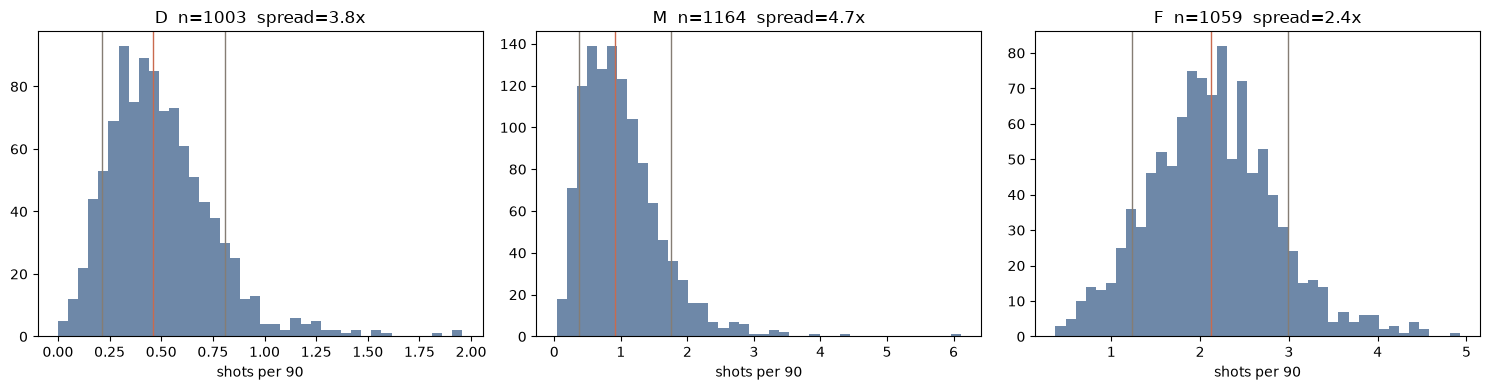

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, pos in zip(axes, ["D", "M", "F"]):
    sub = p[p["position"] == pos]["shots_per90"]
    ax.hist(sub, bins=40, color="#6E88A8", edgecolor="none")
    for q, c in [(0.1, "#857D74"), (0.5, "#C96A4E"), (0.9, "#857D74")]:
        ax.axvline(sub.quantile(q), color=c, lw=1)
    ax.set_title(f"{pos}  n={len(sub)}  spread={sub.quantile(.9)/sub.quantile(.1):.1f}x")
    ax.set_xlabel("shots per 90")
plt.tight_layout()
plt.show()


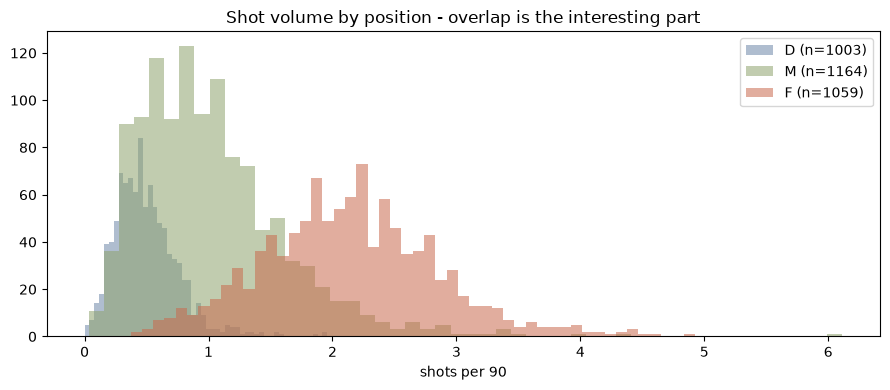

D at p90: 0.808
M at p25: 0.587


In [10]:
# Does shot volume track advanced positioning, or just say 'forward'?
# If the D and M distributions overlap the F range, the metric cuts across the label.
fig, ax = plt.subplots(figsize=(9, 4))
for pos, c in [("D", "#6E88A8"), ("M", "#8FA36E"), ("F", "#C96A4E")]:
    sub = p[p["position"] == pos]["shots_per90"]
    ax.hist(sub, bins=50, alpha=0.55, label=f"{pos} (n={len(sub)})", color=c)
ax.set_xlabel("shots per 90")
ax.legend()
ax.set_title("Shot volume by position - overlap is the interesting part")
plt.tight_layout()
plt.show()

print("D at p90:", p[p.position=="D"]["shots_per90"].quantile(.9).round(3))
print("M at p25:", p[p.position=="M"]["shots_per90"].quantile(.25).round(3))


In [11]:
MIN_FOOT_SHOTS = 25

foot = open_shots.groupby(["id", "shotType"]).agg(
    shots=("is_goal", "size"),
    goals=("is_goal", "sum"),
    xg=("xG", "sum"),
).reset_index()
foot["residual"] = (foot["goals"] - foot["xg"]).round(2)
foot["reliable"] = foot["shots"] >= MIN_FOOT_SHOTS

wide = foot.pivot(index="id", columns="shotType",
                  values=["shots", "goals", "residual", "reliable"])
wide.columns = [f"{a}_{b.lower()}" for a, b in wide.columns]
wide = wide.reset_index()

for c in wide.columns:
    if c.startswith("shots_") or c.startswith("goals_"):
        wide[c] = wide[c].fillna(0)
    if c.startswith("reliable_"):
        wide[c] = wide[c].fillna(False)

p = p.merge(wide, on="id", how="left")

for c in ["shots_leftfoot", "shots_rightfoot", "shots_head", "shots_otherbodypart"]:
    if c not in p.columns:
        p[c] = 0

total_foot = (p["shots_leftfoot"] + p["shots_rightfoot"]).replace(0, np.nan)
p["left_share"] = (p["shots_leftfoot"] / total_foot).round(3)
p["footedness"] = np.where(p["left_share"] > 0.65, "left",
                    np.where(p["left_share"] < 0.35, "right", "two_footed"))
p.loc[total_foot.isna(), "footedness"] = "unknown"

print(p["footedness"].value_counts())


footedness
right         1955
left           826
two_footed     417
unknown         28
Name: count, dtype: int64


In [12]:
# Weaker-foot reliability: how often can we say anything at all about it?
weaker = np.where(p["left_share"] > 0.5, p["shots_rightfoot"], p["shots_leftfoot"])
p["weaker_foot_shots"] = weaker
p["weaker_foot_reliable"] = p["weaker_foot_shots"] >= MIN_FOOT_SHOTS

print(p["weaker_foot_reliable"].value_counts())
print()
print("Of players with a reliable weaker-foot sample, is the weaker foot actually worse?")
sub = p[p["weaker_foot_reliable"]].copy()
print(len(sub), "players qualify")


weaker_foot_reliable
False    2782
True      444
Name: count, dtype: int64

Of players with a reliable weaker-foot sample, is the weaker foot actually worse?
444 players qualify


In [13]:
def share_table(df, col, prefix):
    t = df.groupby(["id", col]).size().unstack(fill_value=0)
    t = t.div(t.sum(axis=1), axis=0).round(3)
    t.columns = [f"{prefix}_{str(c).lower().replace(' ', '_')}" for c in t.columns]
    return t.reset_index()

zone_share = share_table(open_shots, "shot_zone", "zone")
sit_share = share_table(shots, "situation", "sit")

p = p.merge(zone_share, on="id", how="left").merge(sit_share, on="id", how="left")
print([c for c in p.columns if c.startswith("zone_") or c.startswith("sit_")])
p.head(3)


['zone_edge_of_box', 'zone_outside_box', 'zone_six_yard_box', 'sit_directfreekick', 'sit_fromcorner', 'sit_openplay', 'sit_penalty', 'sit_setpiece']


,id,player_name,season_rows,seasons,minutes,games,goals,npg,xG,npxG,assists,xA,shots,key_passes,xGChain,xGBuildup,main_league,main_team,np_shots,np_goals,np_xg,np_residual,np_conversion,avg_shot_xg,pens_taken,...,shots_rightfoot,goals_head,goals_leftfoot,goals_otherbodypart,goals_rightfoot,residual_head,residual_leftfoot,residual_otherbodypart,residual_rightfoot,reliable_head,reliable_leftfoot,reliable_otherbodypart,reliable_rightfoot,left_share,footedness,weaker_foot_shots,weaker_foot_reliable,zone_edge_of_box,zone_outside_box,zone_six_yard_box,sit_directfreekick,sit_fromcorner,sit_openplay,sit_penalty,sit_setpiece
0,6170,André Silva,5,5,7838.0,130.0,48.0,35.0,57.829114,47.234827,13.0,13.993212,269.0,86.0,67.534739,16.349380,bundesliga,RasenBallsport Leipzig,255.0,35.0,47.234851,-12.23,0.1373,0.1852,14.0,...,122,13,7,0,15,-1.52,-4.74,-0.03,-5.94,True,True,False,True,0.326,right,59,True,0.192,0.004,0.804,0.019,0.082,0.796,0.052,0.052
1,4248,Nils Petersen,3,3,2039.0,81.0,14.0,13.0,9.641931,8.884155,1.0,1.347777,58.0,18.0,11.798145,3.757404,bundesliga,Freiburg,57.0,13.0,8.884158,4.12,0.2281,0.1559,1.0,...,20,5,5,0,3,2.12,1.9,-0.03,0.12,False,False,False,False,0.487,two_footed,19,False,0.123,0.035,0.842,0.000,0.190,0.672,0.017,0.121
2,5249,Emil Forsberg,4,4,5207.0,104.0,21.0,13.0,19.612695,12.035008,11.0,12.874584,112.0,86.0,38.456167,19.229688,bundesliga,RasenBallsport Leipzig,102.0,13.0,12.035006,0.96,0.1275,0.1180,10.0,...,68,1,1,0,11,0.04,-1.96,NaN,2.89,False,True,False,True,0.284,right,27,True,0.392,0.020,0.588,0.054,0.080,0.723,0.089,0.054


In [14]:
season = con.execute("""
    SELECT id, year,
           sum(time) AS minutes,
           sum(npg) AS npg,
           sum(npxG) AS npxg,
           sum(shots) AS shots,
           count(*) AS rows_in_year
    FROM players
    GROUP BY id, year
""").df()

print("id-year rows split by transfer:", (season["rows_in_year"] > 1).sum())

season["residual"] = (season["npg"] - season["npxg"]).round(2)
season = season[season["minutes"] >= 450]  # half a season, for a per-year read

_s = season.sort_values(["id", "year"]).copy()
_s["bit"] = _s["year"].astype(int).astype(str) + ": " + _s["residual"].map("{:+.1f}".format)
prog = (_s.groupby("id")["bit"].agg(" -> ".join)
          .rename("season_progression").reset_index())

peak = season.loc[season.groupby("id")["residual"].idxmax()][["id", "year", "residual"]]
peak.columns = ["id", "peak_year", "peak_residual"]
trough = season.loc[season.groupby("id")["residual"].idxmin()][["id", "year", "residual"]]
trough.columns = ["id", "trough_year", "trough_residual"]

p = p.merge(prog, on="id", how="left").merge(peak, on="id", how="left").merge(
    trough, on="id", how="left")
p[["player_name", "season_progression", "peak_year", "trough_year"]].head()


id-year rows split by transfer: 322


,player_name,season_progression,peak_year,trough_year
0,André Silva,2020: +0.7 -> 2021: -4.4 -> 2022: -6.8 -> 2023...,2020.0,2022.0
1,Nils Petersen,2020: +2.3 -> 2021: +2.2,2020.0,2021.0
2,Emil Forsberg,2020: +1.4 -> 2021: -2.5 -> 2022: +0.9,2020.0,2021.0
3,Jonas Hofmann,2020: +0.8 -> 2021: +4.2 -> 2022: +5.4 -> 2023...,2022.0,2023.0
4,Ruben Vargas,2020: +2.1 -> 2021: -2.6 -> 2022: +2.1 -> 2023...,2020.0,2021.0


In [15]:
p = p.sort_values("minutes", ascending=False).reset_index(drop=True)

assert p["id"].is_unique, "duplicate player ids"
assert p["position"].notna().all(), "unclassified position survived the filter"

p.to_csv(OUT, index=False)
print("wrote", OUT)
print(p.shape)
print()
print(p["position"].value_counts())
print()
print(p[["player_name", "main_team", "position", "minutes", "shots_per90",
         "shots_per90_pct", "np_residual", "footedness"]].head(15).to_string(index=False))


wrote /Users/aadvikmazumdar/Projects/OnTarget/data/processed/players_career.csv
(3226, 91)

position
M    1164
F    1059
D    1003
Name: count, dtype: int64

        player_name         main_team position  minutes  shots_per90  shots_per90_pct  np_residual footedness
    James Tarkowski           Everton        D  16114.0       0.6479             76.7        -8.68 two_footed
Giovanni Di Lorenzo            Napoli        D  15938.0       0.7736             87.4        -3.32 two_footed
    Bruno Fernandes Manchester United        F  15733.0       2.6943             79.5        -2.58      right
        Declan Rice          West Ham        M  15427.0       1.1259             65.6         6.00      right
      Ollie Watkins       Aston Villa        F  15366.0       2.5947             76.1        -7.83      right
      Mohamed Salah         Liverpool        F  15097.0       3.5888             97.0        -9.25       left
   Ezri Konsa Ngoyo       Aston Villa        D  15035.0       0.4430    

In [16]:
# Sanity: the highest shot-volume defenders should be recognisable as players who
# push forward. If this list looks random, the metric is not measuring what we think.
(p[p["position"] == "D"]
 .nlargest(15, "shots_per90")[["player_name", "main_team", "minutes",
                                "shots_per90", "shots_per90_pct", "np_goals"]]
 .to_string(index=False))


'           player_name      main_team  minutes  shots_per90  shots_per90_pct  np_goals\n      Federico Dimarco          Inter  10528.0       1.9576            100.0      20.0\n          Nuno Tavares      Marseille   5683.0       1.9479             99.9       7.0\n              Ali Abdi           Nice   1410.0       1.8511             99.8       5.0\nTrent Alexander-Arnold      Liverpool  13445.0       1.5932             99.7      12.0\n           Pedro Porro      Tottenham   6866.0       1.5336             99.6       8.0\n        Theo Hernández       AC Milan  13939.0       1.5302             99.5      22.0\n        Panos Katseris        Lorient   1059.0       1.4448             99.4       1.0\n           Shane Duffy       Brighton   1448.0       1.4296             99.3       1.0\n         Mohamed Fares          Lazio   1736.0       1.3998             99.2       2.0\n   Samuel Iling-Junior       Juventus   1139.0       1.3433             99.1       3.0\n          Tiago Santos         

In [17]:
print(sorted(p.columns.tolist()))

['assists', 'avg_shot_xg', 'avg_shot_xg_pct', 'avg_shot_xg_z', 'col_agreement', 'footedness', 'games', 'goals', 'goals_head', 'goals_leftfoot', 'goals_otherbodypart', 'goals_rightfoot', 'id', 'key_passes', 'kp_per90', 'kp_per90_pct', 'kp_per90_z', 'left_share', 'main_league', 'main_team', 'minutes', 'np_conversion', 'np_conversion_pct', 'np_conversion_z', 'np_goals', 'np_residual', 'np_residual_per90', 'np_residual_per90_pct', 'np_residual_per90_z', 'np_shots', 'np_xg', 'npg', 'npg_per90', 'npg_per90_pct', 'npg_per90_z', 'npxG', 'npxg_per90', 'npxg_per90_pct', 'npxg_per90_z', 'peak_residual', 'peak_year', 'pens_scored', 'pens_taken', 'player_name', 'pos_share', 'position', 'position_ambiguous', 'reliable_head', 'reliable_leftfoot', 'reliable_otherbodypart', 'reliable_rightfoot', 'residual_head', 'residual_leftfoot', 'residual_otherbodypart', 'residual_rightfoot', 'season_progression', 'season_rows', 'seasons', 'shots', 'shots_head', 'shots_leftfoot', 'shots_otherbodypart', 'shots_per90

In [18]:
# The judgement layer. Rules applied once with the full distribution in view -
# which is the point of precomputing findings rather than handing raw numbers to
# a 7B model and hoping it reaches the same conclusion.
#
# Every verdict respects a sample floor. A weaker-foot residual on 12 shots is
# not a finding, and saying so is more useful than inventing one.

def finishing_verdict(row):
    if row["np_shots"] < 30:
        return "insufficient_shots"
    z = row.get("np_residual_per90_z")
    if pd.isna(z):
        return "unknown"
    if z >= 1.0:
        return "systematic_overperformer"
    if z >= 0.35:
        return "slight_overperformer"
    if z <= -1.0:
        return "systematic_underperformer"
    if z <= -0.35:
        return "slight_underperformer"
    return "finishes_to_expectation"


def volume_verdict(row):
    pct = row.get("shots_per90_pct")
    if pd.isna(pct):
        return "unknown"
    pos = row["position"]
    if pct >= 90:
        return "very_high_volume" if pos == "F" else "advanced_for_position"
    if pct >= 70:
        return "high_volume"
    if pct <= 10:
        return "very_low_volume" if pos == "F" else "deep_for_position"
    if pct <= 30:
        return "low_volume"
    return "typical_volume"


def creation_verdict(row):
    xa = row.get("xa_per90_z")
    kp = row.get("kp_per90_z")
    if pd.isna(xa) or pd.isna(kp):
        return "unknown"
    combined = (xa + kp) / 2
    if combined >= 1.0:
        return "primary_creator"
    if combined >= 0.35:
        return "secondary_creator"
    if combined <= -0.75:
        return "not_a_creator"
    return "average_creation"


def foot_verdict(row):
    if row["footedness"] == "unknown":
        return "no_foot_data"
    if row["footedness"] == "two_footed":
        return "two_footed"
    strong = row["footedness"]
    if not row["weaker_foot_reliable"]:
        return f"{strong}_dominant (weaker foot sample too thin to judge)"
    l_res, r_res = row.get("residual_leftfoot"), row.get("residual_rightfoot")
    l_sh, r_sh = row.get("shots_leftfoot", 0), row.get("shots_rightfoot", 0)
    if pd.isna(l_res) or pd.isna(r_res) or l_sh == 0 or r_sh == 0:
        return f"{strong}_dominant"
    better = "left" if (l_res / l_sh) > (r_res / r_sh) else "right"
    if better == strong:
        return f"{strong}_dominant, and the {strong} also finishes better"
    return f"{strong}_dominant, but the {better} finishes better per shot"


def trend_verdict(row):
    pk, tr = row.get("peak_year"), row.get("trough_year")
    if pd.isna(pk) or pd.isna(tr):
        return "unknown"
    if pk > tr:
        return "improving"
    if tr > pk:
        return "declining"
    return "flat"


p["finishing_verdict"] = p.apply(finishing_verdict, axis=1)
p["volume_verdict"] = p.apply(volume_verdict, axis=1)
p["creation_verdict"] = p.apply(creation_verdict, axis=1)
p["foot_verdict"] = p.apply(foot_verdict, axis=1)
p["trend_verdict"] = p.apply(trend_verdict, axis=1)

for c in ["finishing_verdict", "volume_verdict", "creation_verdict", "trend_verdict"]:
    print(c)
    print(p[c].value_counts().to_string())
    print()

finishing_verdict
finishing_verdict
insufficient_shots           1275
finishes_to_expectation       706
slight_overperformer          407
slight_underperformer         380
systematic_underperformer     229
systematic_overperformer      229

volume_verdict
volume_verdict
typical_volume           1286
high_volume               647
low_volume                646
advanced_for_position     218
deep_for_position         216
very_high_volume          107
very_low_volume           106

creation_verdict
creation_verdict
average_creation     1623
not_a_creator         670
secondary_creator     467
primary_creator       466

trend_verdict
trend_verdict
declining    1327
improving    1049
flat          848
unknown         2



In [19]:
# Corpus balance matters. There are 153 team and league chunks in Chroma already.
# Every player above the 900-minute CSV floor would add ~3,200 more, so player
# blocks would be 95% of the corpus and any query without an entity filter would
# retrieve players by default. The CSV keeps everyone for exploration; the
# findings cover players an analyst would plausibly ask about by name.

RAG_MIN_MINUTES = 2700   # ~30 full matches
RAG_MIN_SHOTS = 25

rag_pool = p[(p["minutes"] >= RAG_MIN_MINUTES) & (p["np_shots"] >= RAG_MIN_SHOTS)].copy()
print(f"{len(rag_pool)} players qualify for a findings block")
print(rag_pool.groupby(["main_league", "position"]).size().unstack(fill_value=0))


def _n(v, dp=2, plus=False):
    if pd.isna(v):
        return "n/a"
    return ("{:+." + str(dp) + "f}" if plus else "{:." + str(dp) + "f}").format(v)


def _pct(v):
    return "n/a" if pd.isna(v) else f"{v:.0f}th"


def _top_shares(row, prefix, k=3):
    cols = [c for c in row.index if c.startswith(prefix + "_")]
    vals = [(c[len(prefix) + 1:], row[c]) for c in cols
            if not pd.isna(row[c]) and row[c] > 0]
    vals.sort(key=lambda t: -t[1])
    return " | ".join(f"{n}={s:.0%}" for n, s in vals[:k]) or "n/a"


def player_insight(row):
    pos_word = {"F": "forward", "M": "midfielder", "D": "defender"}.get(
        row["position"], "player")
    bits = [f"{row['player_name']} is a {pos_word} at {row['main_team']}"]

    vol = row["volume_verdict"]
    if vol == "advanced_for_position":
        bits.append(f"shooting {_n(row['shots_per90'])} times per 90 - "
                    f"{_pct(row['shots_per90_pct'])} percentile for a {pos_word}, so he gets "
                    f"into attacking areas far more than most")
    elif vol == "deep_for_position":
        bits.append(f"shooting only {_n(row['shots_per90'])} times per 90 "
                    f"({_pct(row['shots_per90_pct'])} percentile), operating deeper than most")
    else:
        bits.append(f"taking {_n(row['shots_per90'])} shots per 90 "
                    f"({_pct(row['shots_per90_pct'])} percentile)")

    fin = row["finishing_verdict"]
    if fin == "systematic_overperformer":
        bits.append(f"He finishes well above expectation "
                    f"({_n(row['np_residual'], 1, True)} goals vs npxG)")
    elif fin == "systematic_underperformer":
        bits.append(f"He finishes well below expectation "
                    f"({_n(row['np_residual'], 1, True)} goals vs npxG)")
    elif fin == "insufficient_shots":
        bits.append("His shot sample is too small to judge finishing")
    else:
        bits.append("His finishing tracks expectation closely")

    if row["creation_verdict"] == "primary_creator":
        bits.append(f"He is a primary creator ({_n(row['xa_per90'], 2)} xA per 90)")

    if row["trend_verdict"] in ("improving", "declining") and not pd.isna(row.get("peak_year")):
        bits.append(f"Trend is {row['trend_verdict']} since {int(row['peak_year'])}")

    return ". ".join(bits) + "."


def player_block(row):
    L = []
    L.append(f"PLAYER: {row['player_name']} | ID: {int(row['id'])} | "
             f"LEAGUE: {row['main_league']} | TEAM: {row['main_team']}")
    L.append(f"POSITION: {row['position']} (minutes-weighted, {row['pos_share']:.0%} of career) | "
             f"MINUTES: {int(row['minutes'])} | SEASONS: {int(row['seasons'])} | "
             f"GAMES: {int(row['games'])}")
    L.append(f"SHOT VOLUME: {int(row['np_shots'])} non-penalty shots | "
             f"{_n(row['shots_per90'])} per 90 | "
             f"{_pct(row['shots_per90_pct'])} percentile among {row['position']} | "
             f"{_n(row.get('shots_per90_z'), 2, True)}sigma")
    L.append(f"FINISHING: npG={int(row['np_goals'])} | npxG={_n(row['np_xg'])} | "
             f"residual={_n(row['np_residual'], 2, True)} | "
             f"per90={_n(row['np_residual_per90'], 3, True)} | "
             f"{_n(row.get('np_residual_per90_z'), 2, True)}sigma vs {row['position']}")
    L.append(f"SHOT QUALITY: avg_xG_per_shot={_n(row['avg_shot_xg'], 3)} | "
             f"conversion={_n(row['np_conversion'] * 100, 1)}% | "
             f"{_pct(row.get('avg_shot_xg_pct'))} percentile")
    if row["pens_taken"] > 0:
        L.append(f"PENALTIES: {int(row['pens_taken'])} taken, {int(row['pens_scored'])} scored "
                 f"(excluded from all figures above)")
    else:
        L.append("PENALTIES: none taken")
    L.append(f"FOOT: left={int(row.get('shots_leftfoot', 0))} | "
             f"right={int(row.get('shots_rightfoot', 0))} | "
             f"head={int(row.get('shots_head', 0))} | left_share={_n(row['left_share'])}")
    L.append(f"FOOT VERDICT: {row['foot_verdict']}")
    L.append(f"ZONE MIX: {_top_shares(row, 'zone')}")
    L.append(f"SITUATION MIX: {_top_shares(row, 'sit')}")
    L.append(f"CREATION: xA={_n(row['xA'])} | key_passes={int(row['key_passes'])} | "
             f"xA_per90={_n(row['xa_per90'], 3)} ({_pct(row.get('xa_per90_pct'))}) | "
             f"xGChain_per90={_n(row['xgchain_per90'], 3)} ({_pct(row.get('xgchain_per90_pct'))})")
    if isinstance(row.get("season_progression"), str):
        L.append(f"SEASON PROGRESSION (npG - npxG): {row['season_progression']}")
    if not pd.isna(row.get("peak_year")):
        L.append(f"PEAK: {int(row['peak_year'])} ({_n(row['peak_residual'], 1, True)}) | "
                 f"TROUGH: {int(row['trough_year'])} ({_n(row['trough_residual'], 1, True)})")
    L.append(f"VERDICT: finishing={row['finishing_verdict']} | volume={row['volume_verdict']} | "
             f"creation={row['creation_verdict']} | trend={row['trend_verdict']}")
    L.append("INSIGHT: " + player_insight(row))
    return "\n".join(L)


def build_player_rag(league):
    sub = rag_pool[rag_pool["main_league"] == league].copy()
    if not len(sub):
        return None
    sub = sub.sort_values("minutes", ascending=False)

    H = []
    H.append("=====================================")
    H.append(f"PLAYER ANALYSIS | LEAGUE: {league.upper()} | SEASONS: 2020-2024")
    H.append("=====================================")
    H.append(f"SCOPE: {len(sub)} players with {RAG_MIN_MINUTES}+ minutes and "
             f"{RAG_MIN_SHOTS}+ non-penalty shots. Penalties and own goals are excluded "
             f"from every finishing figure. Percentiles and sigma are versus the same "
             f"position across all five leagues.")
    H.append("LEAGUE SUMMARY:")

    for pos in ["F", "M", "D"]:
        ps = sub[sub["position"] == pos]
        if not len(ps):
            continue
        tf = ps.nlargest(1, "np_residual").iloc[0]
        tv = ps.nlargest(1, "shots_per90").iloc[0]
        H.append(f"- {pos}: {len(ps)} players | best finisher: {tf['player_name']} "
                 f"({_n(tf['np_residual'], 1, True)} vs npxG) | highest volume: "
                 f"{tv['player_name']} ({_n(tv['shots_per90'])}/90)")

    w = sub.nsmallest(1, "np_residual").iloc[0]
    H.append(f"- Most wasteful: {w['player_name']} ({_n(w['np_residual'], 1, True)} vs npxG)")
    H.append(f"- Two-footed shooters: {(sub['footedness'] == 'two_footed').sum()}")
    H.append("-------------------------------------")
    H.append("PLAYER PROFILES:")
    H.append("")

    blocks = [player_block(r) for _, r in sub.iterrows()]
    return "\n".join(H) + "\n" + "\n---\n\n".join(blocks) + "\n"


LEAGUES = ["premier_league", "la_liga", "serie_a", "bundesliga", "ligue_1"]
outdir = ROOT / "data" / "rag_findings"

for lg in LEAGUES:
    text = build_player_rag(lg)
    if text is None:
        print("skip", lg)
        continue
    path = outdir / f"players_{lg}.txt"
    path.write_text(text)
    print(f"wrote {path.name}  {text.count('PLAYER: ')} blocks  {len(text):,} chars")

print()
print(build_player_rag("premier_league").split("---")[0][:2200])

1740 players qualify for a findings block
position          D    F    M
main_league                  
bundesliga       70  103  122
la_liga          87  136  130
ligue_1          80  132  124
premier_league  102  143  124
serie_a         100  145  142
wrote players_premier_league.txt  369 blocks  437,605 chars
wrote players_la_liga.txt  353 blocks  414,775 chars
wrote players_serie_a.txt  387 blocks  452,806 chars
wrote players_bundesliga.txt  295 blocks  350,731 chars
wrote players_ligue_1.txt  336 blocks  392,519 chars

PLAYER ANALYSIS | LEAGUE: PREMIER_LEAGUE | SEASONS: 2020-2024
SCOPE: 369 players with 2700+ minutes and 25+ non-penalty shots. Penalties and own goals are excluded from every finishing figure. Percentiles and sigma are versus the same position across all five leagues.
LEAGUE SUMMARY:
- F: 143 players | best finisher: Phil Foden (+16.0 vs npxG) | highest volume: Cristiano Ronaldo (4.52/90)
- M: 124 players | best finisher: James Maddison (+12.5 vs npxG) | highest volum

In [20]:
import json

with open('../eval/eval_questions.json') as f:
    eval_questions = json.load(f)

# Answers computed from the data rather than hardcoded, so they stay checkable.
_pl = rag_pool[rag_pool["main_league"] == "premier_league"]
_best = _pl.nlargest(1, "np_residual").iloc[0]
_worst = _pl.nsmallest(1, "np_residual").iloc[0]
_topd = rag_pool[rag_pool["position"] == "D"].nlargest(1, "shots_per90").iloc[0]
_d10, _d90 = p[p.position == "D"]["shots_per90"].quantile([0.10, 0.90])
_f10, _f90 = p[p.position == "F"]["shots_per90"].quantile([0.10, 0.90])

new_questions = [
    {
        "question": "Which Premier League player overperforms his non-penalty xG the most?",
        "tool": "RAG",
        "answer": f"{_best['player_name']} — {_best['np_residual']:+.1f} goals vs npxG "
                  f"across {int(_best['seasons'])} seasons"
    },
    {
        "question": "Which Premier League player is the most wasteful finisher?",
        "tool": "RAG",
        "answer": f"{_worst['player_name']} — {_worst['np_residual']:+.1f} goals vs npxG"
    },
    {
        "question": "Which defender takes the most shots per 90?",
        "tool": "RAG",
        "answer": f"{_topd['player_name']} ({_topd['main_team']}) — "
                  f"{_topd['shots_per90']:.2f} per 90, "
                  f"{_topd['shots_per90_pct']:.0f}th percentile among defenders"
    },
    {
        "question": "Does shot volume vary more within defenders or within forwards?",
        "tool": "RAG",
        "answer": f"Defenders — p10 to p90 spans {_d10:.2f} to {_d90:.2f} shots/90 "
                  f"({_d90/_d10:.1f}x), versus {_f10:.2f} to {_f90:.2f} for forwards "
                  f"({_f90/_f10:.1f}x). Advancing up the pitch is optional for a defender and "
                  f"definitional for a forward, so volume carries role information for D and M "
                  f"but much less for F"
    },
    {
        "question": "How many players have a weaker-foot sample large enough to judge?",
        "tool": "RAG",
        "answer": f"{int(p['weaker_foot_reliable'].sum())} of {len(p)} players clear "
                  f"{MIN_FOOT_SHOTS} shots on their weaker foot. For everyone else the "
                  f"weaker-foot residual is noise and is reported as such"
    },
    {
        "question": "Are penalties included in a player's finishing residual?",
        "tool": "RAG",
        "answer": "No — penalties are excluded from every finishing figure and reported "
                  "separately. At ~0.76 xG each and always struck with the stronger foot, "
                  "including them would inflate both the preferred-foot share and the "
                  "residual of anyone on penalty duty"
    },
    {
        "question": "How many shots has a specific player taken from the six-yard box?",
        "tool": "DuckDB",
        "answer": "Query shots filtered by player_id and shot_zone='six_yard_box'. Must key on "
                  "player_id, not player name — 24 names map to more than one player, "
                  "including four distinct Danilos"
    },
]

eval_questions.extend(new_questions)

with open('../eval/eval_questions.json', 'w') as f:
    json.dump(eval_questions, f, indent=2)

print(f"Total questions now: {len(eval_questions)}")
for q in new_questions:
    print(" -", q["question"])

Total questions now: 52
 - Which Premier League player overperforms his non-penalty xG the most?
 - Which Premier League player is the most wasteful finisher?
 - Which defender takes the most shots per 90?
 - Does shot volume vary more within defenders or within forwards?
 - How many players have a weaker-foot sample large enough to judge?
 - Are penalties included in a player's finishing residual?
 - How many shots has a specific player taken from the six-yard box?
